In [1]:
# Import Libraries
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load Dataset
fashion_mnist = keras.datasets.fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


### Dataset Exploration

In [3]:
# Printing Number of images
print("Number of training images:", x_train.shape[0])
print("Number of testing images:", x_test.shape[0])

Number of training images: 60000
Number of testing images: 10000


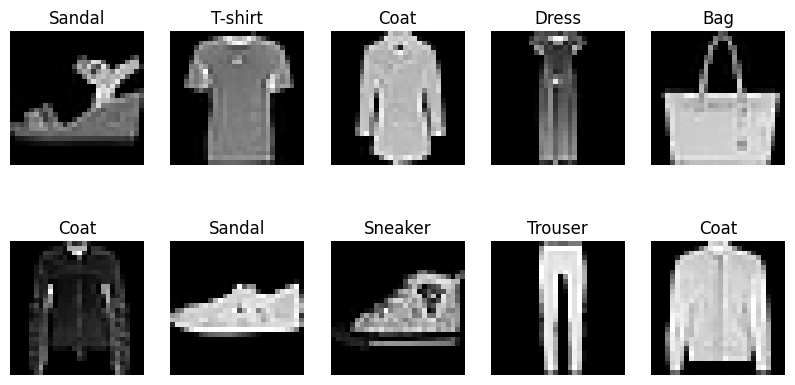

In [4]:
# Displaying 10 random images
class_names = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

plt.figure(figsize=(10,5))

for i in range(10):
    index = np.random.randint(0, len(x_train))

    plt.subplot(2,5,i+1)
    plt.imshow(x_train[index], cmap='gray')
    plt.title(class_names[y_train[index]])
    plt.axis('off')

plt.show()

### Data Preprocessing

In [5]:
# Normalize pixel values
x_train = x_train / 255.0
x_test = x_test / 255.0

In [6]:
# Reshape images of CNN
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

In [7]:

print(x_train.shape)

(60000, 28, 28, 1)


In [8]:
# Converting labels to one-hot encoding
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

### Visualize Class Distribution

In [9]:
# Count images per class
labels = np.argmax(y_train, axis=1)

unique, counts = np.unique(labels, return_counts=True)

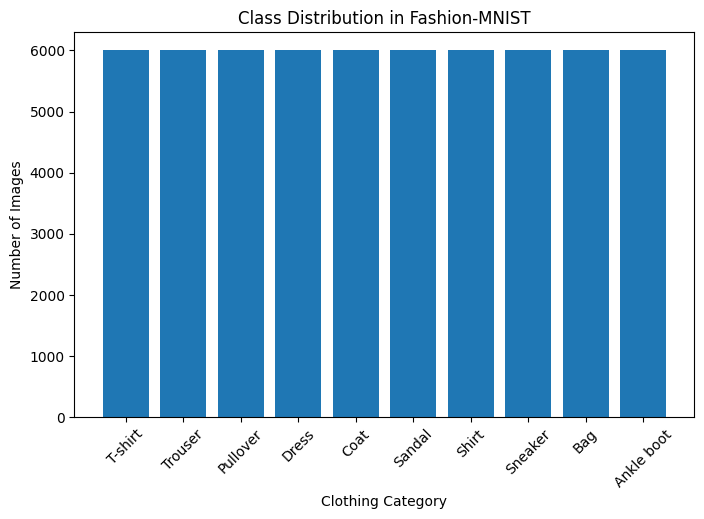

In [10]:
# Bar chart
plt.figure(figsize=(8,5))

plt.bar(class_names, counts)

plt.xlabel("Clothing Category")
plt.ylabel("Number of Images")
plt.title("Class Distribution in Fashion-MNIST")
plt.xticks(rotation=45)

plt.show()

### Building CNN Architecture

In [11]:
model = keras.Sequential([

    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),

    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(64, (3,3), activation='relu'),

    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Flatten(),

    keras.layers.Dense(128, activation='relu'),

    keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
# Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
# Train Model
history =model.fit(x_train, y_train, epochs = 10, batch_size=64, validation_split=0.2)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9693 - loss: 0.0830 - val_accuracy: 0.9700 - val_loss: 0.0810
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9771 - loss: 0.0658 - val_accuracy: 0.9653 - val_loss: 0.0945
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9803 - loss: 0.0568 - val_accuracy: 0.9669 - val_loss: 0.0929
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9826 - loss: 0.0516 - val_accuracy: 0.9612 - val_loss: 0.1052
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9851 - loss: 0.0428 - val_accuracy: 0.9586 - val_loss: 0.1177
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9877 - loss: 0.0358 - val_accuracy: 0.9548 - val_loss: 0.1310
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9875 - loss: 0.0353 - val_accuracy: 0.9556 - val_loss: 0.1329
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9905 - loss: 0.0277 - val_accuracy: 0.

### Model Evaluation

In [17]:
# Evaluate on test dataset
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9129 - loss: 0.4588
Test Loss: 0.47005629539489746
Test Accuracy: 0.9129999876022339


### Displaying 5 test images

In [18]:
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [19]:
# Convert Prediction to class label
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

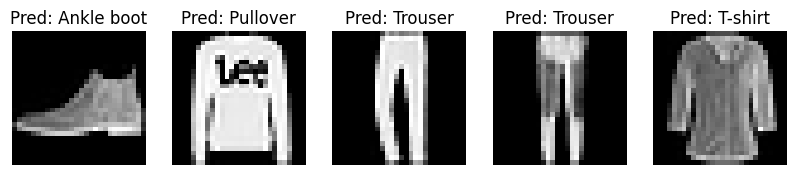

In [20]:
# Showing images with Predictions
class_names = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

plt.figure(figsize=(10,4))

for i in range(5):

    plt.subplot(1,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')

    plt.title("Pred: " + class_names[predicted_classes[i]])
    plt.axis('off')

plt.show()

### Confusion Matrix Analysis

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [23]:
predictions = model.predict(x_test)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [24]:
cm = confusion_matrix(true_classes, predicted_classes)

print(cm)

[[834   1  19  15   4   1 121   0   5   0]
 [  3 978   0  12   2   0   3   0   2   0]
 [ 15   0 889   8  55   0  32   0   1   0]
 [  8   3   9 908  37   0  34   0   1   0]
 [  1   0  32  14 920   1  31   0   1   0]
 [  0   0   0   0   0 973   0  17   0  10]
 [ 87   1  59  18 109   1 717   0   8   0]
 [  0   0   0   0   0   7   0 971   0  22]
 [  4   0   3   1   1   1   5   3 982   0]
 [  0   0   0   0   0   5   0  37   0 958]]


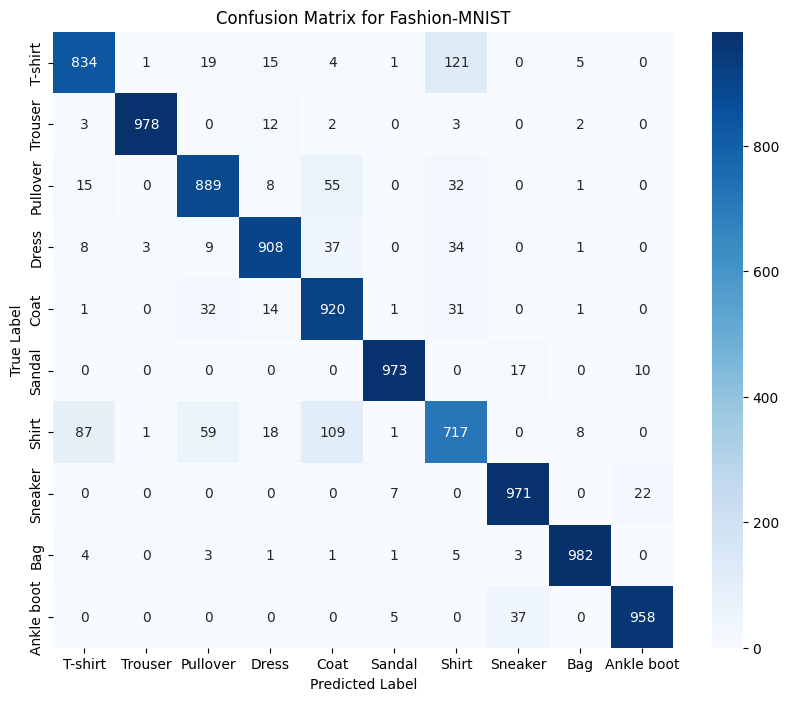

In [25]:
class_names = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

plt.figure(figsize=(10,8))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Fashion-MNIST")

plt.show()

### Improving CNN Architecture

In [26]:
model2 = keras.Sequential([

    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    keras.layers.Conv2D(32, (3,3), activation='relu'),

    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Dropout(0.25),

    keras.layers.Flatten(),

    keras.layers.Dense(128, activation='relu'),

    keras.layers.Dropout(0.5),

    keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [28]:
history2 = model2.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6775 - loss: 0.8899 - val_accuracy: 0.8610 - val_loss: 0.3758
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8487 - loss: 0.4137 - val_accuracy: 0.8848 - val_loss: 0.3093
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8713 - loss: 0.3519 - val_accuracy: 0.8960 - val_loss: 0.2804
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8883 - loss: 0.3103 - val_accuracy: 0.8963 - val_loss: 0.2737
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8929 - loss: 0.2972 - val_accuracy: 0.9083 - val_loss: 0.2527
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9017 - loss: 0.2744 - val_accuracy: 0.9137 - val_loss: 0.2348
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9079 - loss: 0.2506 - val_accuracy: 0.9174 - val_loss: 0.2282
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9126 - loss: 0.2386 - val_accuracy: 0

In [29]:
test_loss2, test_accuracy2 = model2.evaluate(x_test, y_test)

print("Improved Model Test Accuracy:", test_accuracy2)
print("Improved Model Test Loss:", test_loss2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9158 - loss: 0.2440
Improved Model Test Accuracy: 0.9150999784469604
Improved Model Test Loss: 0.23115019500255585


In [30]:
print("Model 1 Accuracy:", test_accuracy)
print("Model 2 Accuracy:", test_accuracy2)

Model 1 Accuracy: 0.9129999876022339
Model 2 Accuracy: 0.9150999784469604


### Misclassification Analysis

In [31]:
# Get predictions
predictions = model.predict(x_test)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

# Find incorrect predictions
misclassified = np.where(predicted_classes != true_classes)[0]

print("Total Misclassified Images:", len(misclassified))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Total Misclassified Images: 870


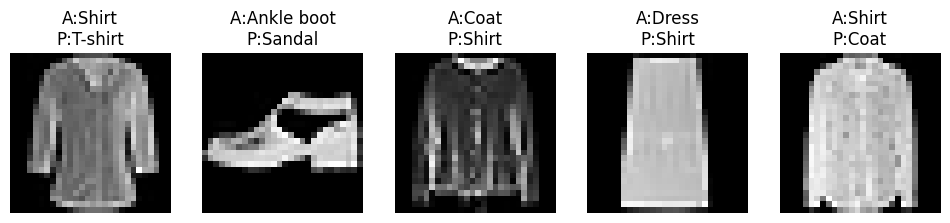

In [32]:
# Displaying 5 Misclassified images
class_names = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

plt.figure(figsize=(12,5))

for i in range(5):

    index = misclassified[i]

    plt.subplot(1,5,i+1)
    plt.imshow(x_test[index].reshape(28,28), cmap='gray')

    actual = class_names[true_classes[index]]
    predicted = class_names[predicted_classes[index]]

    plt.title(f"A:{actual}\nP:{predicted}")
    plt.axis('off')

plt.show()

### Feature Map Visualization

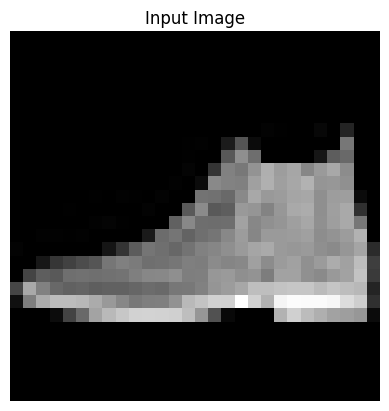

In [33]:
image = x_test[0]

plt.imshow(image.reshape(28,28), cmap='gray')
plt.title("Input Image")
plt.axis('off')
plt.show()

In [35]:
# Extract convolution layer outputs
layer_outputs = [layer.output for layer in model.layers if 'conv' in layer.name]

In [36]:
# Create feature extraction model
feature_model = Model(inputs=model.inputs, outputs=layer_outputs)

In [37]:
# Generate feature maps
feature_maps = feature_model.predict(image.reshape(1,28,28,1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step


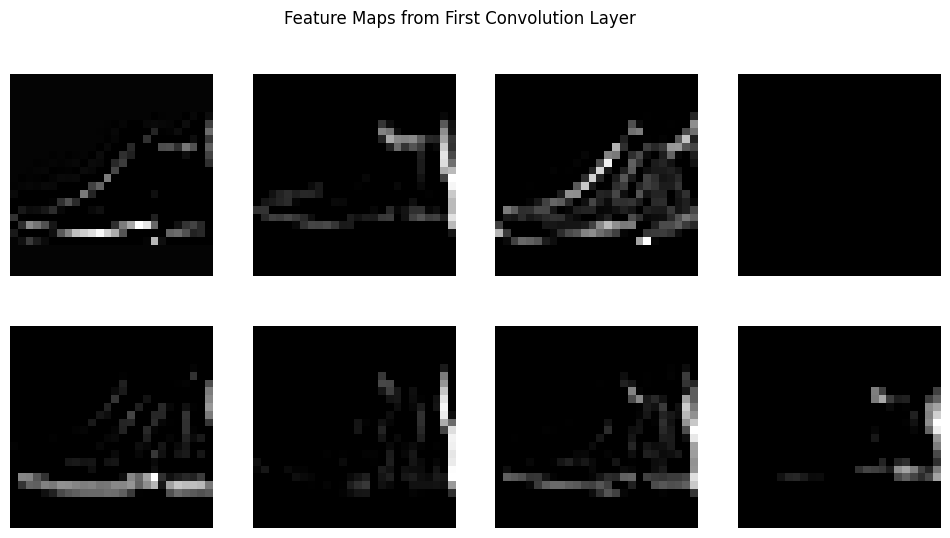

In [38]:
# Visualize feature maps from first conv layer
feature_map = feature_maps[0]

plt.figure(figsize=(12,6))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(feature_map[0,:,:,i], cmap='gray')
    plt.axis('off')

plt.suptitle("Feature Maps from First Convolution Layer")
plt.show()

In [39]:
# Defining Class Names
class_names = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

In [40]:
# Selecting Random Test Images
import random

index = random.randint(0, len(x_test)-1)

image = x_test[index]
true_label = np.argmax(y_test[index])

In [41]:
# Predict using model
prediction = model.predict(image.reshape(1,28,28,1))

predicted_class = np.argmax(prediction)
probability = np.max(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 794ms/step


Actual Label: Dress
Predicted Label: Dress
Prediction Confidence: 0.9999745


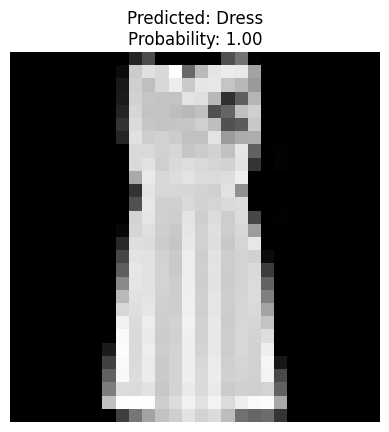

In [42]:
# Display image with prediction
plt.imshow(image.reshape(28,28), cmap='gray')
plt.title(f"Predicted: {class_names[predicted_class]}\nProbability: {probability:.2f}")
plt.axis('off')

print("Actual Label:", class_names[true_label])
print("Predicted Label:", class_names[predicted_class])
print("Prediction Confidence:", probability)

plt.show()